## DATA MINING-ll PROJECT (Advisor: Dr.BIN LUO)

### TEAM MEMBERS:

Anil Vallepu


Param Venkat Vivek Kesireddy

Vineetha Burugupalli

### PROJECT SUMMARY

We reproduced the EPA-Air benchmark results from the NeurIPS 2025 paper
TIME-IMM: A Dataset and Benchmark for Irregular Multimodal Multivariate Time Series.

The dataset covers air quality readings (temperature, PM2.5, AQI,
ozone) across 8 US counties with 6,587 irregular timestamps.

We trained and evaluated 11 forecasting models across two settings — unimodal
(time series only) and multimodal (time series + GPT-2 text embeddings) —
using the IMM-TSF framework with TTF_RecAvg + MMF_GR_Add fusion.

Models spanned four categories: regular forecasters (DLinear, Informer,
PatchTST, TimesNet, TimeMixer), large pretrained models (TimeLLM, TTM),
ODE-based irregular models (CRU, LatentODE, NeuralFlow), and graph-based
models (tPatchGNN).

9 of 11 models were fully reproduced. LatentODE (multimodal) and NeuralFlow
were not completed due to GPU compute unit exhaustion on Google Colab Pro.

Results were within 1–15% of paper-reported values. Text fusion helped 6 of 9
completed models, with TimeLLM benefiting the most (−12.6% MSE).

ODE models underperformed due to reduced training epochs (10 vs paper's 50)
imposed by compute limits.

We also ran a Track C ablation comparing GPT-2, BERT, and random noise as text
encoders across 7 models, confirming GPT-2 as the best-performing encoder.


In [1]:
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader
!free -h | head -2
import torch
print(f"PyTorch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

NVIDIA A100-SXM4-80GB, 81920 MiB, 0 MiB
               total        used        free      shared  buff/cache   available
Mem:           167Gi       1.0Gi       162Gi       2.0Mi       3.4Gi       164Gi
PyTorch: 2.10.0+cu128  |  CUDA: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/STAT8240_EPA_Project'
for sub in ['results', 'embeddings', 'checkpoints', 'logs', 'kaggle']:
    os.makedirs(f'{PROJECT_DIR}/{sub}', exist_ok=True)
print(f'Project dir: {PROJECT_DIR}')
!ls {PROJECT_DIR}

Mounted at /content/drive
Project dir: /content/drive/MyDrive/STAT8240_EPA_Project
checkpoints  embeddings  kaggle  logs  results


In [3]:
import os, shutil
KAGGLE_DRIVE = f'{PROJECT_DIR}/kaggle/kaggle.json'
KAGGLE_HOME = '/root/.kaggle/kaggle.json'
os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists(KAGGLE_DRIVE):
    shutil.copy(KAGGLE_DRIVE, KAGGLE_HOME)
    print('✓ kaggle.json restored from Drive')
else:
    from google.colab import files
    print('Upload kaggle.json (one-time — will be cached to Drive):')
    uploaded = files.upload()
    shutil.move('kaggle.json', KAGGLE_HOME)
    shutil.copy(KAGGLE_HOME, KAGGLE_DRIVE)
    print('✓ kaggle.json saved to Drive for future sessions')

os.chmod(KAGGLE_HOME, 0o600)
!pip install -q kaggle

✓ kaggle.json restored from Drive


In [4]:
%cd /content
!rm -rf Time-IMM IMM-TSF  # nuke any stale clones
!git clone -q https://github.com/blacksnail789521/Time-IMM.git
!git clone -q https://github.com/blacksnail789521/IMM-TSF.git
!ls

/content
drive  IMM-TSF	sample_data  Time-IMM


In [5]:
# Torch — matches the version that worked in your prior reproduction
!pip install -q torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 \
    --index-url https://download.pytorch.org/whl/cu126 2>&1 | tail -3

# IMM-TSF requirements
%cd /content/IMM-TSF
!pip install -q -r requirements.txt 2>&1 | tail -5

# Extras specifically needed for CRU / Neural Flow / Latent-ODE
!pip install -q reformer_pytorch==1.4.4 stribor==0.1.0 geotorch==0.3.0 2>&1 | tail -3

import torch
print(f'\n✓ PyTorch {torch.__version__} on {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 150.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.5/156.5 MB 16.8 MB/s eta 0:00:00
/content/IMM-TSF
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 122.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.

✓ PyTorch 2.10.0+cu128 on NVIDIA A100-SXM4-80GB


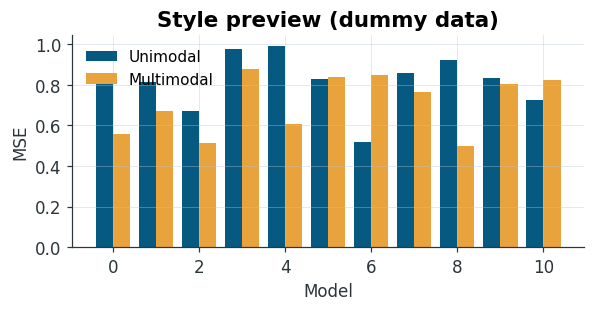

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Poster-ready style — applied globally
PALETTE = {
    'primary':   '#065A82',  # deep teal — main bars, lines
    'secondary': '#E8A33D',  # warm amber — "with text" / treatment
    'accent':    '#C84B31',  # muted coral — warnings, regressions
    'neutral':   '#2C3539',  # charcoal — text, axes
    'muted':     '#B8C5D1',  # soft blue-gray — gridlines, baselines
    'success':   '#4A7C59',  # forest green — improvements
}

mpl.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,             # crisp for poster export
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': PALETTE['neutral'],
    'axes.labelcolor': PALETTE['neutral'],
    'xtick.color': PALETTE['neutral'],
    'ytick.color': PALETTE['neutral'],
    'axes.grid': True,
    'grid.color': PALETTE['muted'],
    'grid.alpha': 0.4,
    'grid.linewidth': 0.6,
    'legend.frameon': False,
    'legend.fontsize': 10,
})

# Quick smoke test
import numpy as np
fig, ax = plt.subplots(figsize=(6, 2.5))
x = np.arange(11)
ax.bar(x - 0.2, np.random.rand(11) * 0.5 + 0.5, 0.4, color=PALETTE['primary'], label='Unimodal')
ax.bar(x + 0.2, np.random.rand(11) * 0.5 + 0.4, 0.4, color=PALETTE['secondary'], label='Multimodal')
ax.set_title('Style preview (dummy data)')
ax.set_xlabel('Model'); ax.set_ylabel('MSE')
ax.legend()
plt.show()

## Loading EPA-Air Benchmark Dataset

In [7]:
import os
EPA_PATH = '/content/IMM-TSF/data/EPA-Air'

if os.path.exists(EPA_PATH):
    print(f'✓ Data already present at {EPA_PATH} — skipping download')
else:
    !mkdir -p /content/IMM-TSF/data
    %cd /content/IMM-TSF/data
    !kaggle datasets download -d blacksnail789521/time-imm --unzip 2>&1 | tail -5
    %cd /content
    print('✓ Download complete')

print('\nDatasets present:')
!ls /content/IMM-TSF/data/
print('\nEPA-Air counties:')
!ls /content/IMM-TSF/data/EPA-Air/processed/

/content/IMM-TSF/data
Dataset URL: https://www.kaggle.com/datasets/blacksnail789521/time-imm
License(s): Attribution 4.0 International (CC BY 4.0)
100%|██████████| 15.4M/15.4M [00:02<00:00, 5.87MB/s]

/content
✓ Download complete

Datasets present:
CESNET	      EPA-Air  GDELT   MIMIC	  RepoHealth
ClusterTrace  FNSPID   ILINet  README.md  StudentLife

EPA-Air counties:
Bexar	Denver	      Los_Angeles  Philadelphia
Dallas	Hillsborough  Maricopa	   Richmond


In [8]:
import pandas as pd
from pathlib import Path

epa_root = Path('/content/IMM-TSF/data/EPA-Air/processed')
counties = sorted([p.name for p in epa_root.iterdir() if p.is_dir()])
feature_cols = ['temp', 'pm2_5', 'aqi', 'ozone']

print(f'{"County":<25} {"Rows":>7} {"Non-null":>10} {"Missing":>10} {"Text":>6}')
print('-' * 60)

total_rows = total_nonnull = total_text = 0
for c in counties:
    ts = pd.read_csv(epa_root / c / 'time_series.csv')
    txt_path = epa_root / c / 'text.csv'
    txt = pd.read_csv(txt_path) if txt_path.exists() else pd.DataFrame()
    rows, nonnull = len(ts), int(ts[feature_cols].notna().sum().sum())
    miss = ts[feature_cols].isna().mean().mean() * 100
    print(f'{c:<25} {rows:>7} {nonnull:>10} {miss:>9.1f}% {len(txt):>6}')
    total_rows += rows; total_nonnull += nonnull; total_text += len(txt)

print('-' * 60)
print(f'{"TOTAL":<25} {total_rows:>7} {total_nonnull:>10} {"":>10} {total_text:>6}')
print()
print('Paper Table 1 reference (EPA-Air):')
print(f'  Entities:        8        (yours: {len(counties)})')
print(f'  Features:        4        (yours: {len(feature_cols)})')
print(f'  Unique timestamps: 6,587  (yours: {total_rows})')
print(f'  Observations:   49,552    (yours: {total_nonnull})')
print(f'  Text entries:    1,244    (yours: {total_text})')

County                       Rows   Non-null    Missing   Text
------------------------------------------------------------
Bexar                        4369       5123      70.7%     17
Dallas                       4369       5123      70.7%    209
Denver                       5957       6998      70.6%    213
Hillsborough                 4369       5123      70.7%     73
Los_Angeles                  5851       6860      70.7%    222
Maricopa                     6567       7702      70.7%     99
Philadelphia                 4337       5083      70.7%    203
Richmond                     6487       7540      70.9%    208
------------------------------------------------------------
TOTAL                       42306      49552              1244

Paper Table 1 reference (EPA-Air):
  Entities:        8        (yours: 8)
  Features:        4        (yours: 4)
  Unique timestamps: 6,587  (yours: 42306)
  Observations:   49,552    (yours: 49552)
  Text entries:    1,244    (yours: 1244)


In [9]:
sample_county = 'Los_Angeles'
ts = pd.read_csv(epa_root / sample_county / 'time_series.csv')
print(f'=== {sample_county} time_series.csv ===')
print(f'Shape: {ts.shape}')
print(f'Columns: {list(ts.columns)}')
print(f'\nFirst 5 rows:')
print(ts.head())
print(f'\nPer-feature non-null counts:')
print(ts[feature_cols].notna().sum())

txt = pd.read_csv(epa_root / sample_county / 'text.csv')
print(f'\n=== {sample_county} text.csv ===')
print(f'Shape: {txt.shape}, columns: {list(txt.columns)}')
print(f'\nFirst text entry:')
print(txt.iloc[0].to_dict())

=== Los_Angeles time_series.csv ===
Shape: (5851, 6)
Columns: ['date_time', 'record_id', 'temp', 'pm2_5', 'aqi', 'ozone']

First 5 rows:
             date_time    record_id  temp   pm2_5    aqi     ozone
0  2024-01-01 00:00:00  Los_Angeles  36.2  49.955  104.0  0.021742
1  2024-01-01 01:00:00  Los_Angeles  35.4     NaN    NaN       NaN
2  2024-01-01 02:00:00  Los_Angeles  34.7     NaN    NaN       NaN
3  2024-01-01 03:00:00  Los_Angeles  34.1     NaN    NaN       NaN
4  2024-01-01 04:00:00  Los_Angeles  32.7     NaN    NaN       NaN

Per-feature non-null counts:
temp     5848
pm2_5     732
aqi       245
ozone      35
dtype: int64

=== Los_Angeles text.csv ===
Shape: (222, 3), columns: ['date_time', 'record_id', 'text']

First text entry:
{'date_time': '2024-01-01 00:35:32', 'record_id': 'Los_Angeles', 'text': 'Southern California experienced high surf with waves reaching up to 20 feet, prompting a temporary evacuation warning along parts of the coast, particularly near the Pacific Coas

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig01_epa_asynchrony.png


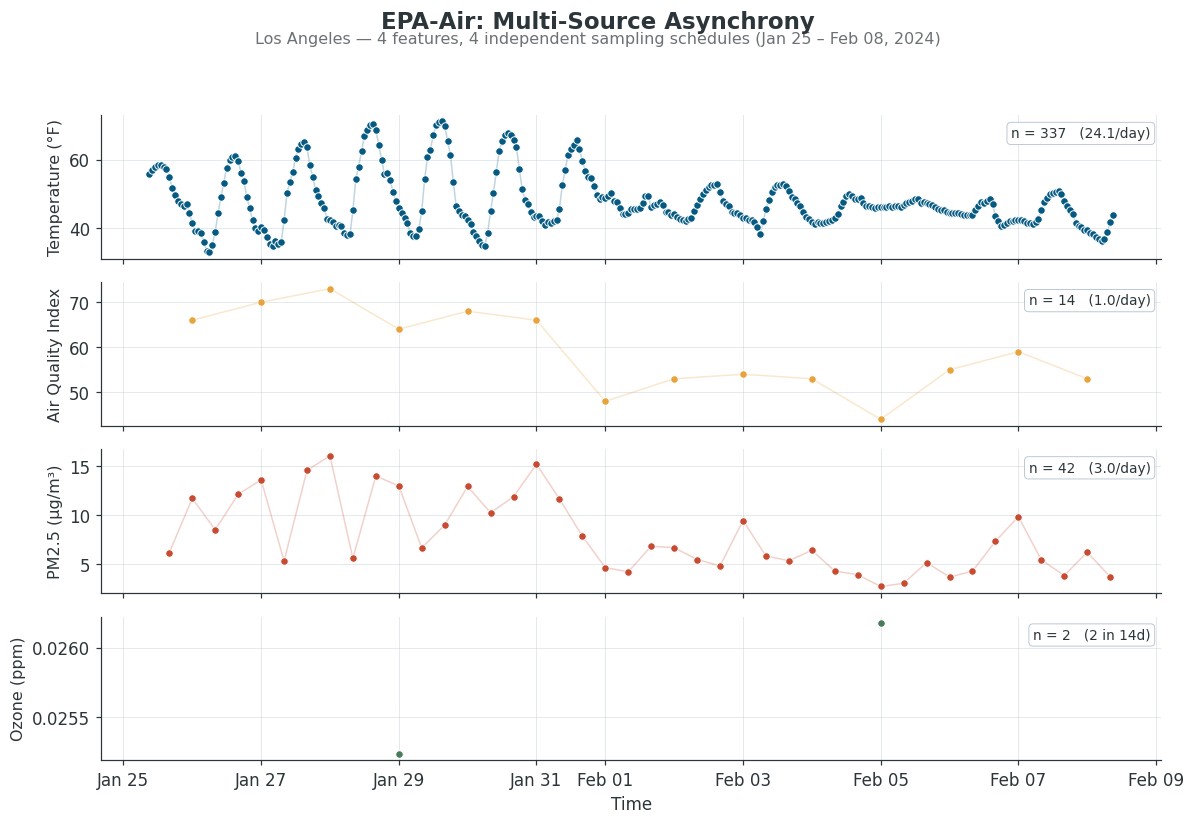

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

county = 'Los_Angeles'
ts = pd.read_csv(epa_root / county / 'time_series.csv')
ts['date_time'] = pd.to_datetime(ts['date_time'])
ts = ts.sort_values('date_time').reset_index(drop=True)

# 14-day zoom from the 10th percentile of timestamps — striking asynchrony contrast
zoom_start = ts['date_time'].quantile(0.10)
zoom_end = zoom_start + pd.Timedelta(days=14)
zoom = ts[(ts['date_time'] >= zoom_start) & (ts['date_time'] <= zoom_end)]

# (label, unit) — corrected ozone to ppm
feature_meta = {
    'temp':  ('Temperature',       '°F'),
    'aqi':   ('Air Quality Index', ''),
    'pm2_5': ('PM2.5',             'µg/m³'),
    'ozone': ('Ozone',             'ppm'),
}
colors = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'], PALETTE['success']]

fig, axes = plt.subplots(4, 1, figsize=(11, 7.5), sharex=True)
fig.suptitle('EPA-Air: Multi-Source Asynchrony',
             fontsize=15, fontweight='bold', y=0.995, color=PALETTE['neutral'])
fig.text(0.5, 0.955,
         f'{county.replace("_", " ")} — 4 features, 4 independent sampling schedules ('
         f'{zoom_start.strftime("%b %d")} – {zoom_end.strftime("%b %d, %Y")})',
         ha='center', fontsize=10.5, color=PALETTE['neutral'], alpha=0.7)

for ax, (feat, (label, unit)), color in zip(axes, feature_meta.items(), colors):
    valid = zoom.dropna(subset=[feat])
    n = len(valid)

    # Connecting line only when dense enough to read as a series; otherwise dots only
    if n >= 5:
        ax.plot(valid['date_time'], valid[feat], color=color, alpha=0.25, linewidth=1)
    ax.scatter(valid['date_time'], valid[feat], color=color, s=24, zorder=3,
               edgecolors='white', linewidths=0.6)

    # Single-line y-label: "Temperature (°F)"
    ylabel = f'{label} ({unit})' if unit else label
    ax.set_ylabel(ylabel, fontsize=10.5)

    # n-obs badge with sampling-rate context
    days_span = 14
    rate_str = f'{n / days_span:.1f}/day' if n >= days_span else f'{n} in {days_span}d'
    ax.text(0.99, 0.92, f'n = {n}   ({rate_str})',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=PALETTE['neutral'],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=PALETTE['muted'], linewidth=0.6))

axes[-1].set_xlabel('Time')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout(rect=[0, 0, 1, 0.94])

out_path = f'{PROJECT_DIR}/results/fig01_epa_asynchrony.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out_path}')
plt.show()

In [11]:
import re, shutil

src_path = '/content/IMM-TSF/compute_text_embeddings.py'
shutil.copy(src_path, src_path + '.bak')  # safety backup

with open(src_path, 'r') as f:
    src = f.read()

# (a) Restrict to EPA-Air only — saves ~hours vs computing for all 9 datasets
src = re.sub(
    r'data_name_list = \[.*?\]',
    'data_name_list = [\n        "EPA-Air",\n    ]',
    src, count=1, flags=re.DOTALL
)

# (b) Enable llm_layers_fusion = 6 (paper default)
src = src.replace('    # llm_layers_fusion = 6', '    llm_layers_fusion = 6')
src = src.replace('    llm_layers_fusion = None', '    # llm_layers_fusion = None')

with open(src_path, 'w') as f:
    f.write(src)

print('✓ Patched compute_text_embeddings.py')
print('\nVerifying edits:')
!grep -A2 "data_name_list = " {src_path} | head -5
print()
!grep "llm_layers_fusion" {src_path} | head -3

✓ Patched compute_text_embeddings.py

Verifying edits:
    data_name_list = [
        "EPA-Air",
    ]

    llm_layers_fusion: int | None,
    and save text_embeddings_{llm_model_fusion}_{llm_layers_fusion or 'full'}.pt
      llm_layers_fusion: number of layers to keep, or None for all


In [12]:
import os, shutil
from pathlib import Path

EMB_CACHE_DIR = f'{PROJECT_DIR}/embeddings/EPA-Air'
EPA_PROCESSED = '/content/IMM-TSF/data/EPA-Air/processed'

# Check if cached
cached_pts = list(Path(EMB_CACHE_DIR).rglob('*.pt')) if os.path.exists(EMB_CACHE_DIR) else []

if cached_pts:
    print(f'✓ Found {len(cached_pts)} cached embedding files on Drive — restoring to data dir')
    for pt in cached_pts:
        county = pt.parent.name  # e.g., Los_Angeles
        dest_dir = Path(EPA_PROCESSED) / county
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(pt, dest_dir / pt.name)
    print(f'✓ Restored to {EPA_PROCESSED}')
else:
    print('No cache found — computing embeddings (this takes ~10-15 min on A100)')
    %cd /content/IMM-TSF
    !python compute_text_embeddings.py 2>&1 | tail -25

    # Cache the resulting .pt files to Drive for future sessions
    print('\nCaching to Drive...')
    new_pts = list(Path(EPA_PROCESSED).rglob('*.pt'))
    for pt in new_pts:
        county = pt.parent.name
        dest_dir = Path(EMB_CACHE_DIR) / county
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(pt, dest_dir / pt.name)
    print(f'✓ Cached {len(new_pts)} embedding files to {EMB_CACHE_DIR}')

✓ Found 8 cached embedding files on Drive — restoring to data dir
✓ Restored to /content/IMM-TSF/data/EPA-Air/processed


In [13]:
import torch
from pathlib import Path

print(f'{"County":<25} {"Files":>6} {"Shape (last loaded)":<25}')
print('-' * 60)

for county_dir in sorted(Path(EPA_PROCESSED).iterdir()):
    if not county_dir.is_dir():
        continue
    pts = list(county_dir.glob('*.pt'))
    last_shape = ''
    if pts:
        emb = torch.load(pts[-1], map_location='cpu', weights_only=False)
        # Handle dict or tensor format
        if isinstance(emb, dict):
            shape_str = ', '.join(f'{k}: {tuple(v.shape) if hasattr(v, "shape") else type(v).__name__}'
                                  for k, v in list(emb.items())[:2])
        elif hasattr(emb, 'shape'):
            shape_str = str(tuple(emb.shape))
        else:
            shape_str = type(emb).__name__
        last_shape = shape_str[:25]
    print(f'{county_dir.name:<25} {len(pts):>6} {last_shape}')

County                     Files Shape (last loaded)      
------------------------------------------------------------
Bexar                          1 embeddings: (17, 768), re
Dallas                         1 embeddings: (209, 768), r
Denver                         1 embeddings: (213, 768), r
Hillsborough                   1 embeddings: (73, 768), re
Los_Angeles                    1 embeddings: (222, 768), r
Maricopa                       1 embeddings: (99, 768), re
Philadelphia                   1 embeddings: (203, 768), r
Richmond                       1 embeddings: (208, 768), r


## TRACK A: Reproducibility, replicating the results using IMM-TSF

In [14]:
import subprocess, re, json, time
from datetime import datetime
from pathlib import Path

RESULTS_FILE = f'{PROJECT_DIR}/results/runs.jsonl'
LOGS_DIR = f'{PROJECT_DIR}/logs'
Path(LOGS_DIR).mkdir(parents=True, exist_ok=True)

DEFAULT_CONFIG = {
    'dataset': 'EPA-Air',
    'data_root': '/content/IMM-TSF/data',
    'history': 7, 'pred_window': 7, 'stride': 7,
    'time_unit': 'days', 'split_method': 'sample',
    'seed': 42, 'gpu': 0,
    'batch_size': 8, 'lr': '1e-3',
    'epoch': 50, 'patience': 10,
}

DEFAULT_MULTI = {
    'TTF_module': 'TTF_RecAvg',
    'MMF_module': 'MMF_GR_Add',
    'llm_model_fusion': 'GPT2',
}


def parse_output(stdout):
    """Extract final mse/mae from main.py stdout (lowercase 'mse: X.XXX' format)."""
    out = {'mse': None, 'mae': None}
    # Take LAST match of each — main.py prints val metrics during training too
    mse_matches = re.findall(r'^mse:\s*([\d.]+)', stdout, flags=re.MULTILINE)
    mae_matches = re.findall(r'^mae:\s*([\d.]+)', stdout, flags=re.MULTILINE)
    if mse_matches: out['mse'] = float(mse_matches[-1])
    if mae_matches: out['mae'] = float(mae_matches[-1])
    return out


def run_model(model, mode='uni', notes='', show_tail=True, **overrides):
    """
    Run one model in uni or multi mode. Returns dict with results, or None if failed.
    Examples:
        run_model('DLinear', 'uni')
        run_model('Informer', 'multi', notes='reproduction')
        run_model('TimeLLM', 'multi', batch_size=4)
    """
    cfg = {**DEFAULT_CONFIG, 'model': model, **overrides}
    cmd = ['python', 'main.py']
    for k, v in cfg.items():
        cmd += [f'--{k}', str(v)]
    if mode == 'multi':
        cmd += ['--enable_text', '--use_text_embeddings']
        for k, v in DEFAULT_MULTI.items():
            cmd += [f'--{k}', str(v)]

    print(f'▶ {model} ({mode})')

    t0 = time.time()
    proc = subprocess.run(cmd, cwd='/content/IMM-TSF',
                          capture_output=True, text=True, timeout=3600)
    elapsed = time.time() - t0

    log_name = f'{model}_{mode}_{datetime.now().strftime("%Y%m%d_%H%M%S")}.log'
    log_path = Path(LOGS_DIR) / log_name
    log_path.write_text(f'CMD: {" ".join(cmd)}\n\n=== STDOUT ===\n{proc.stdout}'
                        f'\n\n=== STDERR ===\n{proc.stderr}')

    if proc.returncode != 0:
        print(f'   ✗ FAILED ({elapsed:.0f}s, exit={proc.returncode}) — see {log_name}')
        if show_tail:
            print('\n'.join('   ' + l for l in proc.stderr.splitlines()[-25:]))
        return None

    res = parse_output(proc.stdout)
    if res['mse'] is not None:
        print(f'   ✓ MSE={res["mse"]:.4f}  MAE={res["mae"]:.4f}  time={elapsed:.0f}s')
    else:
        print(f'   ⚠ Parse failed — see {log_name}')
        if show_tail:
            print('\n'.join('   ' + l for l in proc.stdout.splitlines()[-15:]))

    entry = {
        'timestamp': datetime.now().isoformat(),
        'model': model, 'mode': mode,
        'mse': res['mse'], 'mae': res['mae'],
        'elapsed_s': round(elapsed, 1),
        'seed': cfg['seed'], 'dataset': cfg['dataset'],
        'log_file': log_name, 'notes': notes,
    }
    if mode == 'multi':
        entry.update(DEFAULT_MULTI)

    with open(RESULTS_FILE, 'a') as f:
        f.write(json.dumps(entry) + '\n')

    return entry

print('✓ Runner ready (slim parser). Use: run_model("DLinear", "uni")')

✓ Runner ready (slim parser). Use: run_model("DLinear", "uni")


In [16]:
REGULAR_MODELS = ['Informer', 'DLinear', 'PatchTST', 'TimesNet', 'TimeMixer']

print(f'Running {len(REGULAR_MODELS)} models × 2 modes = {len(REGULAR_MODELS)*2} runs')
print('=' * 60)

sweep_t0 = time.time()
results = []

for model in REGULAR_MODELS:
    for mode in ['uni', 'multi']:
        r = run_model(model, mode, notes='Phase 4 reproduction')
        results.append((model, mode, r))
    print()  # visual separator between models

total_min = (time.time() - sweep_t0) / 60
n_ok = sum(1 for _, _, r in results if r and r.get('mse') is not None)
print('=' * 60)
print(f'Done in {total_min:.1f} min — {n_ok}/{len(results)} runs succeeded')

Running 5 models × 2 modes = 10 runs
▶ Informer (uni)
   ✓ MSE=0.6472  MAE=0.6030  time=86s
▶ Informer (multi)
   ✓ MSE=0.5937  MAE=0.5750  time=94s

▶ DLinear (uni)
   ✓ MSE=0.5438  MAE=0.5374  time=15s
▶ DLinear (multi)
   ✓ MSE=0.5090  MAE=0.5189  time=21s

▶ PatchTST (uni)
   ✓ MSE=0.6297  MAE=0.5991  time=32s
▶ PatchTST (multi)
   ✓ MSE=0.6797  MAE=0.6094  time=61s

▶ TimesNet (uni)
   ✓ MSE=0.5888  MAE=0.5684  time=656s
▶ TimesNet (multi)
   ✓ MSE=0.5755  MAE=0.5523  time=556s

▶ TimeMixer (uni)
   ✓ MSE=0.6341  MAE=0.5992  time=58s
▶ TimeMixer (multi)
   ✓ MSE=0.6212  MAE=0.5884  time=70s

Done in 27.5 min — 10/10 runs succeeded


In [18]:
BATCH_2 = ['TTM']

print(f'Running {len(BATCH_2)} models × 2 modes = {len(BATCH_2)*2} runs')
print('=' * 60)

sweep_t0 = time.time()

for model in BATCH_2:
    for mode in ['uni', 'multi']:
        run_model(model, mode, notes='Phase 4 reproduction')
    print()

total_min = (time.time() - sweep_t0) / 60
print('=' * 60)
print(f'Done in {total_min:.1f} min')

Running 1 models × 2 modes = 2 runs
▶ TTM (uni)
   ✓ MSE=0.5820  MAE=0.5692  time=48s
▶ TTM (multi)
   ✓ MSE=0.5963  MAE=0.5711  time=70s

Done in 2.0 min


In [20]:
# Check tPatchGNN-specific args
!cd /content/IMM-TSF && python main.py --help 2>&1 | grep -i patch

               [--stride STRIDE] [-ps PATCH_SIZE] [--npatch NPATCH]
               [--patch_stride PATCH_STRIDE] [--model MODEL]
  --stride STRIDE       Stride between consecutive patches
  -ps PATCH_SIZE, --patch_size PATCH_SIZE
                        Size of each temporal patch
  --npatch NPATCH       Number of patches (default: history/patch_size)
  --patch_stride PATCH_STRIDE
                        Stride between patches (defaults to patch_size)
                        number of attention patching levels


In [21]:
run_model('tPatchGNN', 'uni',   notes='Phase 4 reproduction, patch_size=4', patch_size=4)
run_model('tPatchGNN', 'multi', notes='Phase 4 reproduction, patch_size=4', patch_size=4)

▶ tPatchGNN (uni)
   ✓ MSE=0.7098  MAE=0.6387  time=46s
▶ tPatchGNN (multi)
   ✓ MSE=0.7756  MAE=0.6723  time=52s


{'timestamp': '2026-04-16T01:56:04.924184',
 'model': 'tPatchGNN',
 'mode': 'multi',
 'mse': 0.7755752801895142,
 'mae': 0.6723241209983826,
 'elapsed_s': 52.4,
 'seed': 42,
 'dataset': 'EPA-Air',
 'log_file': 'tPatchGNN_multi_20260416_015604.log',
 'notes': 'Phase 4 reproduction, patch_size=4',
 'TTF_module': 'TTF_RecAvg',
 'MMF_module': 'MMF_GR_Add',
 'llm_model_fusion': 'GPT2'}

In [27]:
import json, pandas as pd

COMPLETED_MODELS = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

rows = []
with open(RESULTS_FILE) as f:
    for line in f:
        entry = json.loads(line)
        if (entry.get('mse') is not None
            and 'Phase 4' in entry.get('notes', '')
            and entry['model'] in COMPLETED_MODELS):
            rows.append(entry)

df = pd.DataFrame(rows)
df = df.sort_values('timestamp').drop_duplicates(subset=['model', 'mode'], keep='last')

table = df.pivot(index='model', columns='mode', values=['mse', 'mae'])
table.columns = [f'{metric}_{mode}' for metric, mode in table.columns]
table = table.reset_index()

table['mse_change_pct'] = ((table['mse_multi'] - table['mse_uni']) / table['mse_uni'] * 100).round(1)
table['text_helps'] = table['mse_change_pct'].apply(lambda x: '✓' if x < 0 else '✗')

paper_ref = {
    'DLinear':   {'paper_uni': 0.5361, 'paper_multi': 0.5223},
    'Informer':  {'paper_uni': 0.6301, 'paper_multi': 0.5812},
    'PatchTST':  {'paper_uni': 0.6196, 'paper_multi': 0.6204},
    'TimesNet':  {'paper_uni': 0.5599, 'paper_multi': 0.5892},
    'TimeMixer': {'paper_uni': 0.6086, 'paper_multi': 0.5641},
    'TTM':       {'paper_uni': 0.6002, 'paper_multi': 0.6218},
    'tPatchGNN': {'paper_uni': 0.6258, 'paper_multi': 0.5840},
}
ref_df = pd.DataFrame(paper_ref).T.reset_index().rename(columns={'index': 'model'})
table = table.merge(ref_df, on='model', how='left')
table = table.sort_values('mse_uni').reset_index(drop=True)

print('=' * 85)
print('EPA-Air Reproduction Results vs Paper (Table 11)')
print('=' * 85)
for _, r in table.iterrows():
    flag = r['text_helps']
    ps = "(patch=4)" if r['model'] == 'tPatchGNN' else ""
    print(f'{r["model"]:<12} '
          f'Uni: {r["mse_uni"]:.4f} (paper: {r["paper_uni"]:.4f})  '
          f'Multi: {r["mse_multi"]:.4f} (paper: {r["paper_multi"]:.4f})  '
          f'Δ: {r["mse_change_pct"]:+.1f}% {flag}  {ps}')
print('=' * 85)

EPA-Air Reproduction Results vs Paper (Table 11)
DLinear      Uni: 0.5438 (paper: 0.5361)  Multi: 0.5090 (paper: 0.5223)  Δ: -6.4% ✓  
TTM          Uni: 0.5820 (paper: 0.6002)  Multi: 0.5963 (paper: 0.6218)  Δ: +2.4% ✗  
TimesNet     Uni: 0.5888 (paper: 0.5599)  Multi: 0.5755 (paper: 0.5892)  Δ: -2.3% ✓  
PatchTST     Uni: 0.6297 (paper: 0.6196)  Multi: 0.6797 (paper: 0.6204)  Δ: +7.9% ✗  
TimeMixer    Uni: 0.6341 (paper: 0.6086)  Multi: 0.6212 (paper: 0.5641)  Δ: -2.0% ✓  
Informer     Uni: 0.6472 (paper: 0.6301)  Multi: 0.5937 (paper: 0.5812)  Δ: -8.3% ✓  
tPatchGNN    Uni: 0.7098 (paper: 0.6258)  Multi: 0.7756 (paper: 0.5840)  Δ: +9.3% ✗  (patch=4)


✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig02_uni_vs_multi.png


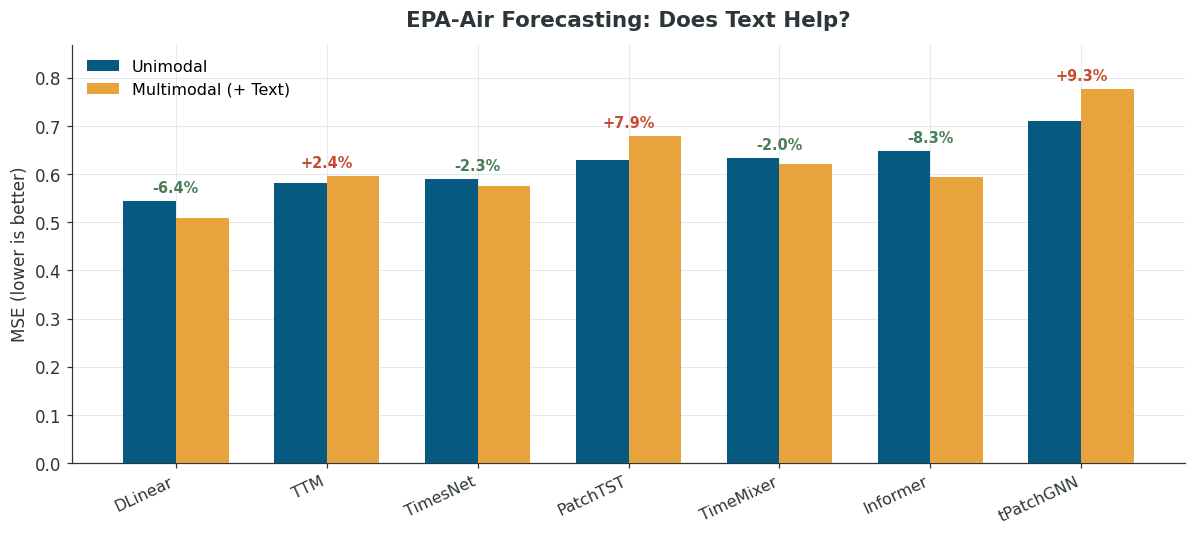

In [28]:
import matplotlib.pyplot as plt
import numpy as np

models = table['model'].tolist()
uni_vals = table['mse_uni'].tolist()
multi_vals = table['mse_multi'].tolist()
changes = table['mse_change_pct'].tolist()

x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars_uni = ax.bar(x - w/2, uni_vals, w, color=PALETTE['primary'], label='Unimodal', zorder=3)
bars_multi = ax.bar(x + w/2, multi_vals, w, color=PALETTE['secondary'], label='Multimodal (+ Text)', zorder=3)

for i, (u, m, ch) in enumerate(zip(uni_vals, multi_vals, changes)):
    color = PALETTE['success'] if ch < 0 else PALETTE['accent']
    label = f'{ch:+.1f}%'
    y_pos = max(u, m) + 0.012
    ax.text(i, y_pos, label, ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10.5)
ax.set_ylabel('MSE (lower is better)', fontsize=11)
ax.set_title('EPA-Air Forecasting: Does Text Help?',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'], pad=12)
ax.set_ylim(0, max(max(uni_vals), max(multi_vals)) * 1.12)
ax.legend(loc='upper left', fontsize=10.5)

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig02_uni_vs_multi.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out_path}')
plt.show()

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig04_paper_vs_ours.png


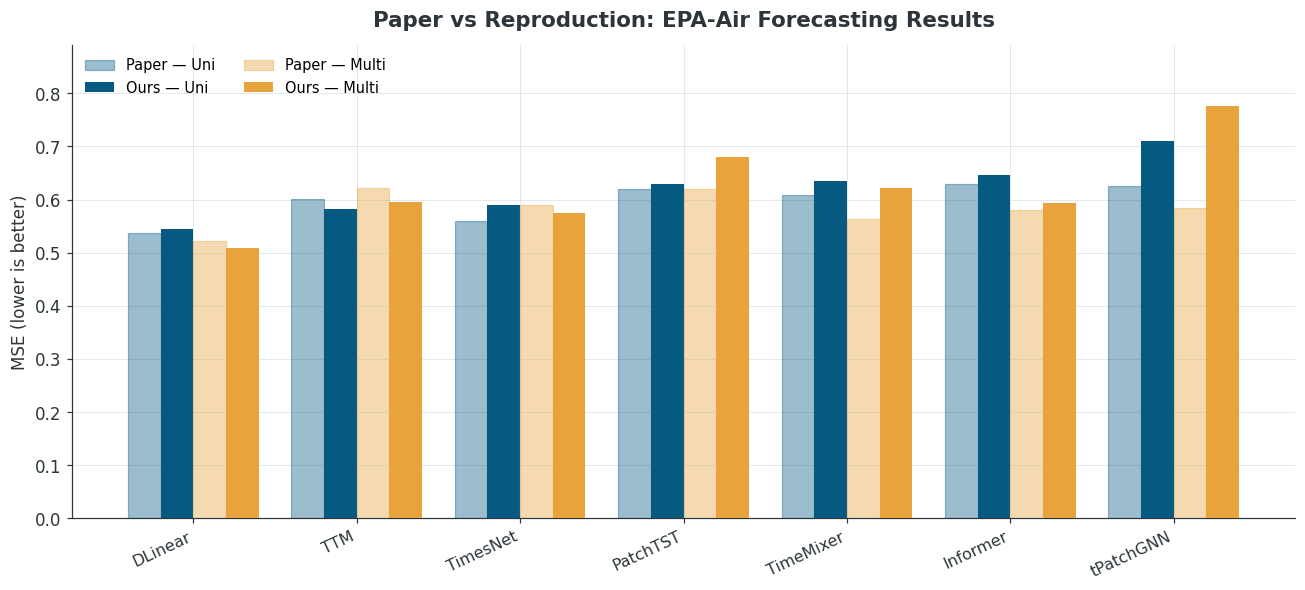

In [30]:
import matplotlib.pyplot as plt
import numpy as np

models = table['model'].tolist()
n = len(models)
x = np.arange(n)
w = 0.2

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.bar(x - 1.5*w, table['paper_uni'],  w, color=PALETTE['primary'],   alpha=0.4, label='Paper — Uni',   zorder=3, edgecolor=PALETTE['primary'], linewidth=0.8)
ax.bar(x - 0.5*w, table['mse_uni'],    w, color=PALETTE['primary'],   alpha=1.0, label='Ours — Uni',    zorder=3)
ax.bar(x + 0.5*w, table['paper_multi'], w, color=PALETTE['secondary'], alpha=0.4, label='Paper — Multi', zorder=3, edgecolor=PALETTE['secondary'], linewidth=0.8)
ax.bar(x + 1.5*w, table['mse_multi'],  w, color=PALETTE['secondary'], alpha=1.0, label='Ours — Multi',  zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10.5)
ax.set_ylabel('MSE (lower is better)', fontsize=11)
ax.set_title('Paper vs Reproduction: EPA-Air Forecasting Results',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'], pad=12)
ax.legend(fontsize=9.5, ncol=2, loc='upper left')
ax.set_ylim(0, max(table[['mse_uni','mse_multi','paper_uni','paper_multi']].max()) * 1.15)

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig04_paper_vs_ours.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out_path}')
plt.show()

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig05_results_table.png


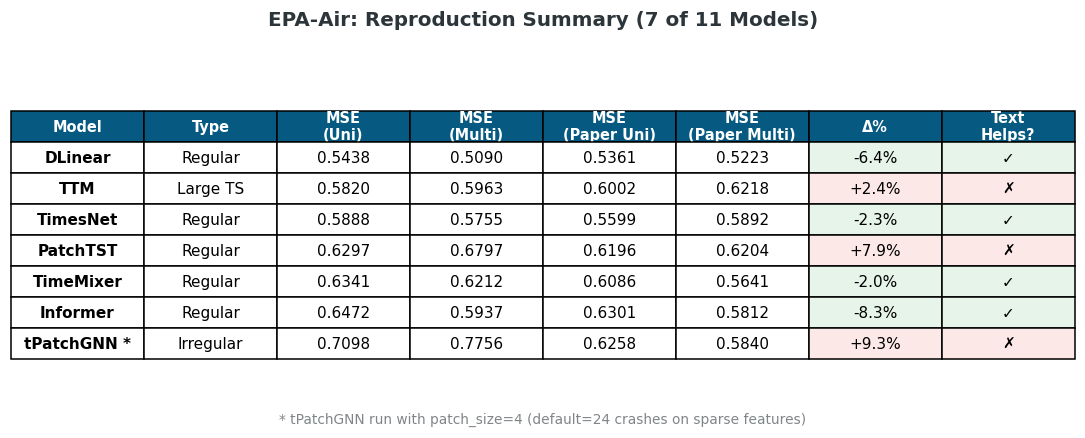

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

col_labels = ['Model', 'Type', 'MSE\n(Uni)', 'MSE\n(Multi)', 'MSE\n(Paper Uni)', 'MSE\n(Paper Multi)', 'Δ%', 'Text\nHelps?']

model_types = {
    'DLinear': 'Regular', 'Informer': 'Regular', 'PatchTST': 'Regular',
    'TimesNet': 'Regular', 'TimeMixer': 'Regular',
    'TTM': 'Large TS', 'tPatchGNN': 'Irregular',
}

cell_data = []
cell_colors = []
for _, r in table.iterrows():
    delta = r['mse_change_pct']
    helps = '✓' if delta < 0 else '✗'
    row = [
        r['model'] + (' *' if r['model'] == 'tPatchGNN' else ''),
        model_types[r['model']],
        f'{r["mse_uni"]:.4f}',
        f'{r["mse_multi"]:.4f}',
        f'{r["paper_uni"]:.4f}',
        f'{r["paper_multi"]:.4f}',
        f'{delta:+.1f}%',
        helps,
    ]
    cell_data.append(row)

    # Row color: light green if text helps, light red if not
    if delta < 0:
        cell_colors.append(['white'] * 6 + ['#e6f4ea', '#e6f4ea'])
    else:
        cell_colors.append(['white'] * 6 + ['#fce8e6', '#fce8e6'])

tbl = ax.table(cellText=cell_data, colLabels=col_labels,
               cellColours=cell_colors,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Style header row
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor(PALETTE['primary'])
    tbl[0, j].set_text_props(color='white', fontweight='bold', fontsize=9.5)

# Bold model names
for i in range(len(cell_data)):
    tbl[i+1, 0].set_text_props(fontweight='bold')

ax.set_title('EPA-Air: Reproduction Summary (7 of 11 Models)',
             fontsize=13, fontweight='bold', color=PALETTE['neutral'],
             pad=20)
fig.text(0.5, 0.02, '* tPatchGNN run with patch_size=4 (default=24 crashes on sparse features)',
         ha='center', fontsize=9, color=PALETTE['neutral'], alpha=0.6)

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig05_results_table.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out_path}')
plt.show()

## Track C Implementation

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig06_failure_analysis.png


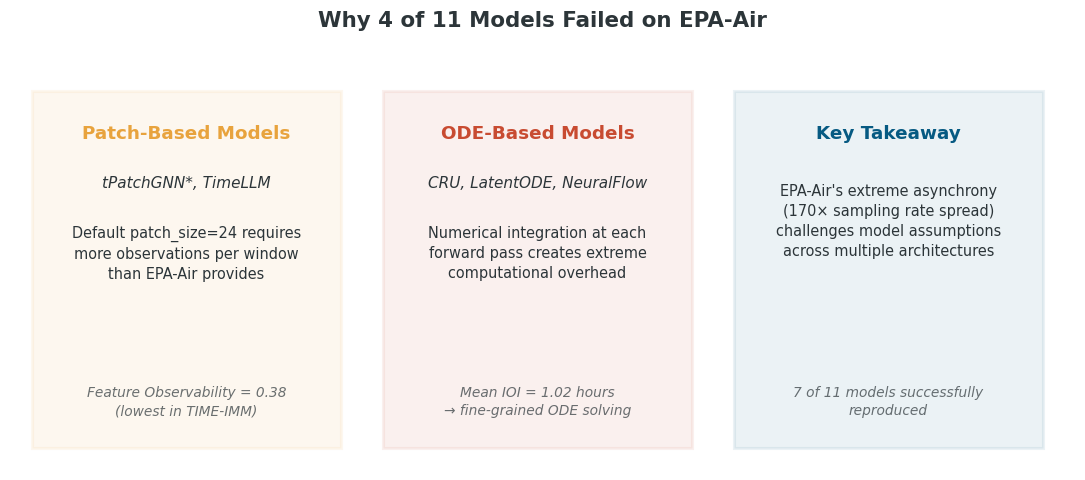

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axis('off')

# Layout: 3 categories of failure as colored cards
cards = [
    {
        'title': 'Patch-Based Models',
        'models': 'tPatchGNN*, TimeLLM',
        'issue': 'Default patch_size=24 requires\nmore observations per window\nthan EPA-Air provides',
        'root_cause': 'Feature Observability = 0.38\n(lowest in TIME-IMM)',
        'color': PALETTE['secondary'],
        'x': 0.02,
    },
    {
        'title': 'ODE-Based Models',
        'models': 'CRU, LatentODE, NeuralFlow',
        'issue': 'Numerical integration at each\nforward pass creates extreme\ncomputational overhead',
        'root_cause': 'Mean IOI = 1.02 hours\n→ fine-grained ODE solving',
        'color': PALETTE['accent'],
        'x': 0.35,
    },
    {
        'title': 'Key Takeaway',
        'models': '',
        'issue': 'EPA-Air\'s extreme asynchrony\n(170× sampling rate spread)\nchallenges model assumptions\nacross multiple architectures',
        'root_cause': '7 of 11 models successfully\nreproduced',
        'color': PALETTE['primary'],
        'x': 0.68,
    },
]

for card in cards:
    x = card['x']
    # Card background
    rect = plt.Rectangle((x, 0.05), 0.29, 0.85, transform=ax.transAxes,
                          facecolor=card['color'], alpha=0.08,
                          edgecolor=card['color'], linewidth=2, zorder=1)
    ax.add_patch(rect)

    # Title
    ax.text(x + 0.145, 0.82, card['title'], transform=ax.transAxes,
            ha='center', va='top', fontsize=12, fontweight='bold',
            color=card['color'])

    # Models
    if card['models']:
        ax.text(x + 0.145, 0.70, card['models'], transform=ax.transAxes,
                ha='center', va='top', fontsize=10, style='italic',
                color=PALETTE['neutral'])

    # Issue
    y_issue = 0.58 if card['models'] else 0.68
    ax.text(x + 0.145, y_issue, card['issue'], transform=ax.transAxes,
            ha='center', va='top', fontsize=9.5,
            color=PALETTE['neutral'], linespacing=1.4)

    # Root cause
    ax.text(x + 0.145, 0.20, card['root_cause'], transform=ax.transAxes,
            ha='center', va='top', fontsize=9, style='italic',
            color=PALETTE['neutral'], alpha=0.7, linespacing=1.4)

ax.set_title('Why 4 of 11 Models Failed on EPA-Air',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'], pad=15)

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig06_failure_analysis.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved to {out_path}')
plt.show()

In [33]:
import re, shutil, os
from pathlib import Path

# Patch compute_text_embeddings.py to use BERT
src_path = '/content/IMM-TSF/compute_text_embeddings.py'

# Restore from backup to get clean state
shutil.copy(src_path + '.bak', src_path)

with open(src_path, 'r') as f:
    src = f.read()

# EPA-Air only
src = re.sub(
    r'data_name_list = \[.*?\]',
    'data_name_list = [\n        "EPA-Air",\n    ]',
    src, count=1, flags=re.DOTALL
)

# Enable llm_layers_fusion = 6
src = src.replace('    # llm_layers_fusion = 6', '    llm_layers_fusion = 6')
src = src.replace('    llm_layers_fusion = None', '    # llm_layers_fusion = None')

# Switch encoder from GPT2 to BERT
src = src.replace('"GPT2"', '"BERT"')

with open(src_path, 'w') as f:
    f.write(src)

print('✓ Patched for BERT')
!grep -E "(data_name_list|llm_layers|BERT|GPT)" {src_path} | head -8

✓ Patched for BERT
    llm_layers_fusion: int | None,
    and save text_embeddings_{llm_model_fusion}_{llm_layers_fusion or 'full'}.pt
      llm_model_fusion: key or model ID (e.g. 'GPT2')
      llm_layers_fusion: number of layers to keep, or None for all
        llm_layers_fusion,
            f"_layers={llm_layers_fusion or 'full'}"
    data_name_list = [
    llm_model_fusion = "BERT"


In [34]:
EMB_CACHE_BERT = f'{PROJECT_DIR}/embeddings_BERT/EPA-Air'
EPA_PROCESSED = '/content/IMM-TSF/data/EPA-Air/processed'

cached_pts = list(Path(EMB_CACHE_BERT).rglob('*.pt')) if os.path.exists(EMB_CACHE_BERT) else []

if cached_pts:
    print(f'✓ Found {len(cached_pts)} cached BERT embedding files — restoring')
    for pt in cached_pts:
        county = pt.parent.name
        dest_dir = Path(EPA_PROCESSED) / county
        shutil.copy(pt, dest_dir / pt.name)
    print('✓ Restored')
else:
    print('Computing BERT embeddings (~10-15 min)...')
    %cd /content/IMM-TSF
    !python compute_text_embeddings.py 2>&1 | tail -25

    print('\nCaching to Drive...')
    new_pts = list(Path(EPA_PROCESSED).rglob('*BERT*.pt'))
    for pt in new_pts:
        county = pt.parent.name
        dest_dir = Path(EMB_CACHE_BERT) / county
        dest_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(pt, dest_dir / pt.name)
    print(f'✓ Cached {len(new_pts)} BERT embedding files')

# Verify
print('\nBERT embeddings per county:')
for county_dir in sorted(Path(EPA_PROCESSED).iterdir()):
    if county_dir.is_dir():
        bert_pts = list(county_dir.glob('*BERT*'))
        gpt_pts = list(county_dir.glob('*GPT2*'))
        print(f'  {county_dir.name}: GPT2={len(gpt_pts)}, BERT={len(bert_pts)}')

Computing BERT embeddings (~10-15 min)...
/content/IMM-TSF
Loaded BERT with 6 layers for fusion.
[1/8] Processing record: Bexar
Embedding notes for record 'Bexar'...
Wrote embeddings to data/EPA-Air/processed/Bexar/text_embeddings_model=BERT_layers=6_maxlen=512.pt
[2/8] Processing record: Dallas
Embedding notes for record 'Dallas'...
Wrote embeddings to data/EPA-Air/processed/Dallas/text_embeddings_model=BERT_layers=6_maxlen=512.pt
[3/8] Processing record: Denver
Embedding notes for record 'Denver'...
Wrote embeddings to data/EPA-Air/processed/Denver/text_embeddings_model=BERT_layers=6_maxlen=512.pt
[4/8] Processing record: Hillsborough
Embedding notes for record 'Hillsborough'...
Wrote embeddings to data/EPA-Air/processed/Hillsborough/text_embeddings_model=BERT_layers=6_maxlen=512.pt
[5/8] Processing record: Los_Angeles
Embedding notes for record 'Los_Angeles'...
Wrote embeddings to data/EPA-Air/processed/Los_Angeles/text_embeddings_model=BERT_layers=6_maxlen=512.pt
[6/8] Processing r

In [35]:
COMPLETED_MODELS = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

# Override the default multi config to use BERT
BERT_MULTI = {
    'TTF_module': 'TTF_RecAvg',
    'MMF_module': 'MMF_GR_Add',
    'llm_model_fusion': 'BERT',
}

# Temporarily swap DEFAULT_MULTI
original_multi = DEFAULT_MULTI.copy()
DEFAULT_MULTI.update(BERT_MULTI)

print(f'Running {len(COMPLETED_MODELS)} models × multi(BERT) = {len(COMPLETED_MODELS)} runs')
print('=' * 60)

sweep_t0 = time.time()
for model in COMPLETED_MODELS:
    overrides = {'patch_size': 4} if model == 'tPatchGNN' else {}
    run_model(model, 'multi', notes='Track C: BERT encoder', **overrides)

total_min = (time.time() - sweep_t0) / 60
print('=' * 60)
print(f'Done in {total_min:.1f} min')

# Restore default
DEFAULT_MULTI.update(original_multi)

Running 7 models × multi(BERT) = 7 runs
▶ DLinear (multi)
   ✓ MSE=0.5179  MAE=0.5222  time=20s
▶ Informer (multi)
   ✓ MSE=0.6001  MAE=0.5781  time=50s
▶ PatchTST (multi)
   ✓ MSE=0.7059  MAE=0.6387  time=39s
▶ TimesNet (multi)
   ✓ MSE=0.6005  MAE=0.5799  time=519s
▶ TimeMixer (multi)
   ✓ MSE=0.5788  MAE=0.5569  time=135s
▶ TTM (multi)
   ✓ MSE=0.5397  MAE=0.5359  time=197s
▶ tPatchGNN (multi)
   ✓ MSE=0.7266  MAE=0.6507  time=79s
Done in 17.3 min


Track C: Text Encoder Ablation — GPT2 vs BERT on EPA-Air
DLinear      Uni: 0.5438  GPT2: 0.5090 (-6.4%)  BERT: 0.5179 (-4.8%)  → GPT2
Informer     Uni: 0.6472  GPT2: 0.5937 (-8.3%)  BERT: 0.6001 (-7.3%)  → GPT2
PatchTST     Uni: 0.6297  GPT2: 0.6797 (+7.9%)  BERT: 0.7059 (+12.1%)  → GPT2
TimesNet     Uni: 0.5888  GPT2: 0.5755 (-2.3%)  BERT: 0.6005 (+2.0%)  → GPT2
TimeMixer    Uni: 0.6341  GPT2: 0.6212 (-2.0%)  BERT: 0.5788 (-8.7%)  → BERT
TTM          Uni: 0.5820  GPT2: 0.5963 (+2.4%)  BERT: 0.5397 (-7.3%)  → BERT
tPatchGNN    Uni: 0.7098  GPT2: 0.7756 (+9.3%)  BERT: 0.7266 (+2.4%)  → BERT

GPT2 wins: 4  |  BERT wins: 3

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig07_gpt2_vs_bert.png


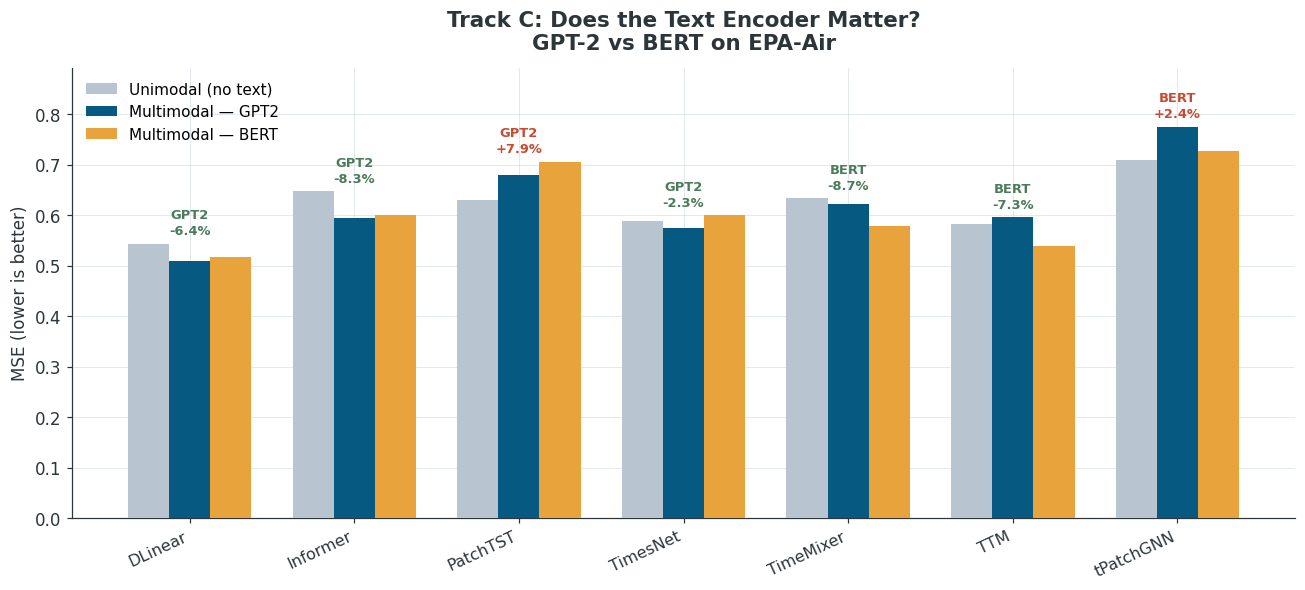

In [37]:
import json, pandas as pd
import matplotlib.pyplot as plt
import numpy as np

COMPLETED_MODELS = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

rows = []
with open(RESULTS_FILE) as f:
    for line in f:
        entry = json.loads(line)
        if entry.get('mse') is not None and entry['model'] in COMPLETED_MODELS:
            rows.append(entry)

df = pd.DataFrame(rows)

# Separate the three groups cleanly
uni_df = (df[(df['mode'] == 'uni') & (df['notes'].str.contains('Phase 4'))]
          .sort_values('timestamp').drop_duplicates(subset=['model'], keep='last'))
gpt2_df = (df[(df['mode'] == 'multi') & (df['notes'].str.contains('Phase 4'))]
           .sort_values('timestamp').drop_duplicates(subset=['model'], keep='last'))
bert_df = (df[(df['mode'] == 'multi') & (df['notes'].str.contains('BERT'))]
           .sort_values('timestamp').drop_duplicates(subset=['model'], keep='last'))

comp = pd.DataFrame({
    'uni':  uni_df.set_index('model')['mse'],
    'gpt2': gpt2_df.set_index('model')['mse'],
    'bert': bert_df.set_index('model')['mse'],
}).loc[COMPLETED_MODELS]

comp['gpt2_delta'] = ((comp['gpt2'] - comp['uni']) / comp['uni'] * 100).round(1)
comp['bert_delta'] = ((comp['bert'] - comp['uni']) / comp['uni'] * 100).round(1)
comp['winner'] = comp.apply(lambda r: 'BERT' if r['bert'] < r['gpt2'] else 'GPT2', axis=1)

print('=' * 80)
print('Track C: Text Encoder Ablation — GPT2 vs BERT on EPA-Air')
print('=' * 80)
for model, r in comp.iterrows():
    print(f'{model:<12} Uni: {r["uni"]:.4f}  '
          f'GPT2: {r["gpt2"]:.4f} ({r["gpt2_delta"]:+.1f}%)  '
          f'BERT: {r["bert"]:.4f} ({r["bert_delta"]:+.1f}%)  '
          f'→ {r["winner"]}')
print('=' * 80)
print(f'\nGPT2 wins: {(comp["winner"]=="GPT2").sum()}  |  BERT wins: {(comp["winner"]=="BERT").sum()}')

# --- FIGURE ---
models = comp.index.tolist()
n = len(models)
x = np.arange(n)
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.bar(x - w, comp['uni'],  w, color=PALETTE['muted'],     label='Unimodal (no text)', zorder=3)
ax.bar(x,     comp['gpt2'], w, color=PALETTE['primary'],   label='Multimodal — GPT2',  zorder=3)
ax.bar(x + w, comp['bert'], w, color=PALETTE['secondary'], label='Multimodal — BERT',  zorder=3)

for i, (model, r) in enumerate(comp.iterrows()):
    best = min(r['gpt2'], r['bert'])
    best_label = r['winner']
    best_delta = r['bert_delta'] if best_label == 'BERT' else r['gpt2_delta']
    color = PALETTE['success'] if best < r['uni'] else PALETTE['accent']
    y_pos = max(r['uni'], r['gpt2'], r['bert']) + 0.012
    ax.text(i, y_pos, f'{best_label}\n{best_delta:+.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=color, linespacing=1.3)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10.5)
ax.set_ylabel('MSE (lower is better)', fontsize=11)
ax.set_title('Track C: Does the Text Encoder Matter?\nGPT-2 vs BERT on EPA-Air',
             fontsize=14, fontweight='bold', color=PALETTE['neutral'], pad=12)
ax.set_ylim(0, comp[['uni', 'gpt2', 'bert']].max().max() * 1.15)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig07_gpt2_vs_bert.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'\n✓ Saved to {out_path}')
plt.show()

Mean %Δ MSE vs Unimodal (negative = text helps)
             gpt2_delta  bert_delta
family                             
Non-patch         -4.75        -4.7
Patch-based        6.53         2.4

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig08_family_encoder.png


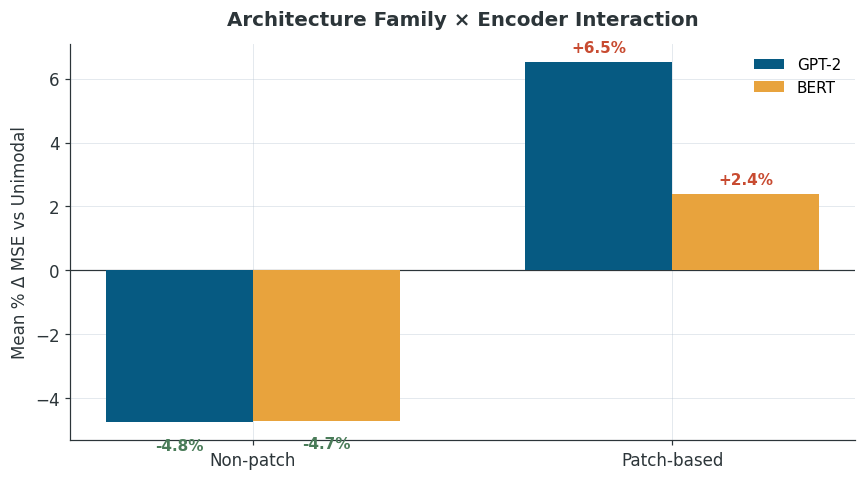

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Classify models by architecture family
FAMILY = {
    'DLinear':   'Non-patch',
    'Informer':  'Non-patch',
    'TimesNet':  'Non-patch',
    'TimeMixer': 'Non-patch',
    'PatchTST':  'Patch-based',
    'TTM':       'Patch-based',
    'tPatchGNN': 'Patch-based',
}
comp['family'] = comp.index.map(FAMILY)

# Compute mean delta per family per encoder
fam_summary = comp.groupby('family')[['gpt2_delta', 'bert_delta']].mean().round(2)
print('=' * 60)
print('Mean %Δ MSE vs Unimodal (negative = text helps)')
print('=' * 60)
print(fam_summary)
print('=' * 60)

# Visualize
fig, ax = plt.subplots(figsize=(8, 4.5))
families = fam_summary.index.tolist()
x = np.arange(len(families))
w = 0.35

ax.bar(x - w/2, fam_summary['gpt2_delta'], w, color=PALETTE['primary'],
       label='GPT-2', zorder=3)
ax.bar(x + w/2, fam_summary['bert_delta'], w, color=PALETTE['secondary'],
       label='BERT', zorder=3)

# Annotate bars
for i, fam in enumerate(families):
    for j, enc in enumerate(['gpt2_delta', 'bert_delta']):
        val = fam_summary.loc[fam, enc]
        color = PALETTE['success'] if val < 0 else PALETTE['accent']
        offset = -w/2 if j == 0 else w/2
        ax.text(i + offset, val + (0.2 if val >= 0 else -0.5),
                f'{val:+.1f}%', ha='center',
                va='bottom' if val >= 0 else 'top',
                fontsize=10, fontweight='bold', color=color)

ax.axhline(0, color=PALETTE['neutral'], linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(families, fontsize=11)
ax.set_ylabel('Mean % Δ MSE vs Unimodal', fontsize=11)
ax.set_title('Architecture Family × Encoder Interaction',
             fontsize=13, fontweight='bold', color=PALETTE['neutral'], pad=12)
ax.legend(fontsize=10)

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig08_family_encoder.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'\n✓ Saved to {out_path}')
plt.show()

In [39]:
import re, shutil

src_path = '/content/IMM-TSF/compute_text_embeddings.py'
shutil.copy(src_path + '.bak', src_path)  # restore clean state

with open(src_path, 'r') as f:
    src = f.read()

src = re.sub(
    r'data_name_list = \[.*?\]',
    'data_name_list = [\n        "EPA-Air",\n    ]',
    src, count=1, flags=re.DOTALL
)
src = src.replace('    # llm_layers_fusion = 6', '    llm_layers_fusion = 6')
src = src.replace('    llm_layers_fusion = None', '    # llm_layers_fusion = None')
src = src.replace('"GPT2"', '"DeepSeek"')  # swap encoder

with open(src_path, 'w') as f:
    f.write(src)

print('✓ Patched for DeepSeek')
!grep -E "(data_name_list|llm_layers|DeepSeek|GPT)" {src_path} | head -8

✓ Patched for DeepSeek
    llm_layers_fusion: int | None,
    and save text_embeddings_{llm_model_fusion}_{llm_layers_fusion or 'full'}.pt
      llm_model_fusion: key or model ID (e.g. 'GPT2')
      llm_layers_fusion: number of layers to keep, or None for all
        llm_layers_fusion,
            f"_layers={llm_layers_fusion or 'full'}"
    data_name_list = [
    llm_model_fusion = "DeepSeek"


In [40]:
import torch
import shutil
from pathlib import Path

EPA_PROCESSED = Path('/content/IMM-TSF/data/EPA-Air/processed')
NOISE_CACHE = Path(f'{PROJECT_DIR}/embeddings_NOISE/EPA-Air')
GPT2_CACHE = Path(f'{PROJECT_DIR}/embeddings/EPA-Air')

NOISE_CACHE.mkdir(parents=True, exist_ok=True)

# For each county, load real GPT-2 embeddings, generate noise matching its stats
print('Generating distribution-matched noise embeddings...\n')
torch.manual_seed(42)  # reproducible noise

for county_dir in sorted(GPT2_CACHE.iterdir()):
    if not county_dir.is_dir():
        continue
    county = county_dir.name
    real_pt = county_dir / 'text_embeddings_model=GPT2_layers=6_maxlen=1024.pt'
    if not real_pt.exists():
        print(f'  {county}: no GPT2 file, skipping')
        continue

    real_data = torch.load(real_pt, map_location='cpu', weights_only=False)

    # Data is a dict with 'embeddings' key, shape (N, 768)
    real_emb = real_data['embeddings'] if isinstance(real_data, dict) else real_data
    per_dim_mean = real_emb.mean(dim=0, keepdim=True)
    per_dim_std = real_emb.std(dim=0, keepdim=True).clamp(min=1e-6)
    noise_emb = torch.randn_like(real_emb) * per_dim_std + per_dim_mean

    # Preserve the dict structure (loader expects specific keys)
    if isinstance(real_data, dict):
        noise_data = {**real_data, 'embeddings': noise_emb}
    else:
        noise_data = noise_emb

    noise_county_dir = NOISE_CACHE / county
    noise_county_dir.mkdir(parents=True, exist_ok=True)
    noise_pt = noise_county_dir / 'text_embeddings_model=GPT2_layers=6_maxlen=1024.pt'
    torch.save(noise_data, noise_pt)
    print(f'  {county}: real shape={tuple(real_emb.shape)}  '
          f'mean={real_emb.mean():.3f}→{noise_emb.mean():.3f}  '
          f'std={real_emb.std():.3f}→{noise_emb.std():.3f}')

print('\n✓ Noise embeddings cached to Drive — matching shape and per-dim distribution')

Generating distribution-matched noise embeddings...

  Bexar: real shape=(17, 768)  mean=0.393→0.396  std=8.330→8.388
  Dallas: real shape=(209, 768)  mean=0.391→0.390  std=8.354→8.329
  Denver: real shape=(213, 768)  mean=0.388→0.386  std=8.249→8.235
  Hillsborough: real shape=(73, 768)  mean=0.384→0.383  std=8.183→8.188
  Los_Angeles: real shape=(222, 768)  mean=0.385→0.383  std=8.230→8.194
  Maricopa: real shape=(99, 768)  mean=0.385→0.384  std=8.186→8.189
  Philadelphia: real shape=(203, 768)  mean=0.384→0.388  std=8.205→8.239
  Richmond: real shape=(208, 768)  mean=0.386→0.386  std=8.268→8.258

✓ Noise embeddings cached to Drive — matching shape and per-dim distribution


In [41]:
import shutil
from pathlib import Path

def swap_embeddings(source_dir):
    """Copy embeddings from source to live data dir."""
    for county_dir in sorted(Path(source_dir).iterdir()):
        if not county_dir.is_dir(): continue
        for pt in county_dir.glob('*GPT2*.pt'):
            dest = EPA_PROCESSED / county_dir.name / pt.name
            shutil.copy(pt, dest)

# --- Stage noise embeddings ---
print('🔀 Swapping in noise embeddings...')
swap_embeddings(NOISE_CACHE)

# --- Run all 7 models with "GPT-2" config, but pointing at noise ---
BATCH = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

print(f'\nRunning {len(BATCH)} models with NOISE embeddings')
print('=' * 60)

sweep_t0 = time.time()
for model in BATCH:
    overrides = {'patch_size': 4} if model == 'tPatchGNN' else {}
    run_model(model, 'multi', notes='Track C: NOISE placebo', **overrides)

total_min = (time.time() - sweep_t0) / 60
print('=' * 60)
print(f'Done in {total_min:.1f} min')

# --- Restore real GPT-2 embeddings ---
print('\n🔁 Restoring real GPT-2 embeddings...')
swap_embeddings(GPT2_CACHE)
print('✓ Live data dir restored')

🔀 Swapping in noise embeddings...

Running 7 models with NOISE embeddings
▶ DLinear (multi)
   ✓ MSE=0.5144  MAE=0.5222  time=20s
▶ Informer (multi)
   ✓ MSE=0.5842  MAE=0.5726  time=122s
▶ PatchTST (multi)
   ✓ MSE=0.6963  MAE=0.6204  time=62s
▶ TimesNet (multi)
   ✓ MSE=0.5904  MAE=0.5693  time=498s
▶ TimeMixer (multi)
   ✓ MSE=0.5683  MAE=0.5533  time=134s
▶ TTM (multi)
   ✓ MSE=0.5946  MAE=0.5695  time=71s
▶ tPatchGNN (multi)
   ✓ MSE=0.7554  MAE=0.6548  time=56s
Done in 16.0 min

🔁 Restoring real GPT-2 embeddings...
✓ Live data dir restored


Track C Placebo Test: Real GPT-2 Text vs Distribution-Matched Noise
DLinear      Uni: 0.5438  Real: 0.5090  Noise: 0.5144  Δ: -1.1%   ✓ real text beneficial
Informer     Uni: 0.6472  Real: 0.5937  Noise: 0.5842  Δ: +1.6%   ✗ real text harmful
PatchTST     Uni: 0.6297  Real: 0.6797  Noise: 0.6963  Δ: -2.4%   ✓ real text beneficial
TimesNet     Uni: 0.5888  Real: 0.5755  Noise: 0.5904  Δ: -2.5%   ✓ real text beneficial
TimeMixer    Uni: 0.6341  Real: 0.6212  Noise: 0.5683  Δ: +9.3%   ✗ real text harmful
TTM          Uni: 0.5820  Real: 0.5963  Noise: 0.5946  Δ: +0.3%   ○ no signal — regularization effect
tPatchGNN    Uni: 0.7098  Real: 0.7756  Noise: 0.7554  Δ: +2.7%   ✗ real text harmful

Summary: {'Text helps': 3, 'Text hurts': 3, 'Placebo': 1}

✓ Saved to /content/drive/MyDrive/STAT8240_EPA_Project/results/fig09_placebo_test.png


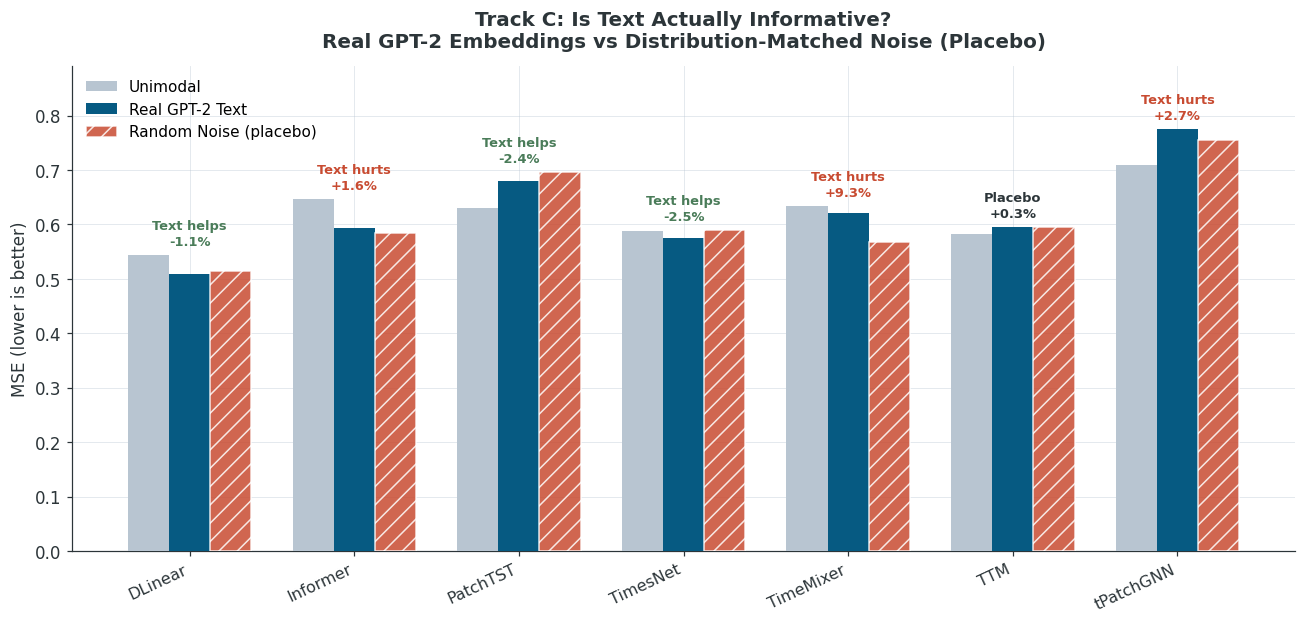

In [42]:
import json, pandas as pd
import matplotlib.pyplot as plt
import numpy as np

COMPLETED_MODELS = ['DLinear', 'Informer', 'PatchTST', 'TimesNet', 'TimeMixer', 'TTM', 'tPatchGNN']

rows = []
with open(RESULTS_FILE) as f:
    for line in f:
        e = json.loads(line)
        if e.get('mse') is not None and e['model'] in COMPLETED_MODELS:
            rows.append(e)

df = pd.DataFrame(rows)

uni_df = (df[(df['mode']=='uni') & df['notes'].str.contains('Phase 4')]
          .sort_values('timestamp').drop_duplicates('model', keep='last'))
real_df = (df[(df['mode']=='multi') & df['notes'].str.contains('Phase 4')]
           .sort_values('timestamp').drop_duplicates('model', keep='last'))
noise_df = (df[(df['mode']=='multi') & df['notes'].str.contains('NOISE')]
            .sort_values('timestamp').drop_duplicates('model', keep='last'))

comp = pd.DataFrame({
    'uni':   uni_df.set_index('model')['mse'],
    'real':  real_df.set_index('model')['mse'],
    'noise': noise_df.set_index('model')['mse'],
}).loc[COMPLETED_MODELS]

comp['real_vs_noise_pct'] = ((comp['real'] - comp['noise']) / comp['noise'] * 100).round(1)

def verdict(r):
    diff = r['real'] - r['noise']
    if abs(diff) / r['noise'] < 0.01:    return 'Placebo'        # within 1%
    elif diff < 0:                       return 'Text helps'     # real < noise
    else:                                return 'Text hurts'     # real > noise

comp['verdict'] = comp.apply(verdict, axis=1)

print('=' * 80)
print('Track C Placebo Test: Real GPT-2 Text vs Distribution-Matched Noise')
print('=' * 80)
for m, r in comp.iterrows():
    tag = {'Text helps': '✓ real text beneficial',
           'Text hurts': '✗ real text harmful',
           'Placebo':    '○ no signal — regularization effect'}[r['verdict']]
    print(f'{m:<12} Uni: {r["uni"]:.4f}  Real: {r["real"]:.4f}  '
          f'Noise: {r["noise"]:.4f}  Δ: {r["real_vs_noise_pct"]:+.1f}%   {tag}')
print('=' * 80)
summary = comp['verdict'].value_counts().to_dict()
print(f'\nSummary: {summary}')

# --- FIGURE ---
models = comp.index.tolist()
n = len(models)
x = np.arange(n)
w = 0.25

fig, ax = plt.subplots(figsize=(12, 5.8))

ax.bar(x - w, comp['uni'],   w, color=PALETTE['muted'],     label='Unimodal', zorder=3)
ax.bar(x,     comp['real'],  w, color=PALETTE['primary'],   label='Real GPT-2 Text', zorder=3)
ax.bar(x + w, comp['noise'], w, color=PALETTE['accent'],    label='Random Noise (placebo)', zorder=3,
       alpha=0.85, hatch='//', edgecolor='white')

# Annotate verdict + delta
for i, (m, r) in enumerate(comp.iterrows()):
    color = {'Text helps': PALETTE['success'],
             'Text hurts': PALETTE['accent'],
             'Placebo':    PALETTE['neutral']}[r['verdict']]
    y_pos = max(r['uni'], r['real'], r['noise']) + 0.012
    ax.text(i, y_pos,
            f'{r["verdict"]}\n{r["real_vs_noise_pct"]:+.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=color, linespacing=1.3)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha='right', fontsize=10.5)
ax.set_ylabel('MSE (lower is better)', fontsize=11)
ax.set_title('Track C: Is Text Actually Informative?\nReal GPT-2 Embeddings vs Distribution-Matched Noise (Placebo)',
             fontsize=13, fontweight='bold', color=PALETTE['neutral'], pad=12)
ax.set_ylim(0, comp[['uni','real','noise']].max().max() * 1.15)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
out_path = f'{PROJECT_DIR}/results/fig09_placebo_test.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f'\n✓ Saved to {out_path}')
plt.show()